# HDB Resale Price Prediction — v15 (final)

**Goal:** beat personal-best $22,094 on the Kaggle leaderboard. v14 reached **$21,831 CV** with a 6-base stack; v15 prunes that stack down to its load-bearing parts and documents every step as a learning artefact.

---

## What changed from v14

| Change | Reason |
|---|---|
| Drop **HGBT-Quantile** base | Meta weight was exactly **0.000** — the stacker rejected it. Pure dead weight + 442s wall time. |
| Drop **RandomForest** base | Meta weight 0.060 with $24,042 solo RMSE — paid 2,653s for 6% influence. Diversity not worth the cost when 4 GBDTs already cover the space. |
| Drop **walk-forward diagnostic cell** | Already declared informational only; leaderboard scoring is i.i.d. |
| Drop **`price_tier_enc`** feature | Target-encoded `geo_cluster` while `geo_cluster` is already a column AND `te_town`/`te_town_type` capture the macro level — triple-counting the same signal. |
| Drop **`floor_ratio`** alias | Literal duplicate of `storey_pct`. |
| Expanded **markdown** | Each section now opens with *what / why / what to watch* and closes with a 💡 **Lesson** box. |
| Added **visualisations** | LightGBM feature importance, residuals by flat type, temporal drift (random-KFold vs walk-forward gap). |

---

## Stack composition (v15)

| Base | Family | Loss | Role |
|---|---|---|---|
| LGBM-Huber (3-seed avg) | GBDT, leaf-wise | Huber (robust) | Top contributor — handles outliers |
| LGBM-MSE (3-seed avg)   | GBDT, leaf-wise | Squared error | Lowest solo RMSE |
| XGBoost                 | GBDT, level-wise | Squared error | Different split algorithm → diversity |
| Per-segment LGBM blend  | GBDT, partitioned by `flat_type_ord` | Squared error | Specialist for non-uniform price dynamics across flat sizes |

Meta-learner: **non-negative `LinearRegression`** on out-of-fold predictions (5-fold inner KFold for honest stack RMSE).

---

## Notebook conventions

- Sections are numbered. Every section starts with a markdown intro and ends with a 💡 **Lesson** insight you can quote in your own notes later.
- Visualisation cells are tagged `*-viz` and intentionally separated from compute cells so you can re-run plots without recomputing models.
- Excluded test IDs **182002, 82198** (host-flagged data-entry errors).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import BallTree
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings, datetime, time
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

T0 = time.time()
def lap(tag, t):
    print(f"  [{tag}] {time.time()-t:.1f}s")

def rmse_log(yt, yp):
    return float(np.sqrt(mean_squared_error(yt, yp)))

def rmse_sgd(yt, yp):
    return float(np.sqrt(mean_squared_error(np.expm1(yt), np.expm1(yp))))

In [2]:
ENV = 'kaggle'   # 'local' | 'kaggle' | 'colab'
_cfg = {
    'local':  {'data': '../data',                                     'out': '../notebooks'},
    'kaggle': {'data': '/kaggle/input/datasets/englikhong/myownhdb3', 'out': '/kaggle/working'},
    'colab':  {'data': '/content/drive/MyDrive/hdb',                  'out': '/content/drive/MyDrive/hdb/output'},
}
DATA_DIR, OUT_DIR = _cfg[ENV]['data'], _cfg[ENV]['out']
print(f"DATA_DIR={DATA_DIR}\nOUT_DIR={OUT_DIR}")

DATA_DIR=/kaggle/input/datasets/englikhong/myownhdb3
OUT_DIR=/kaggle/working


## 1. Load

In [3]:
train = pd.read_csv(f'{DATA_DIR}/train.csv', low_memory=False).reset_index(drop=True)
test  = pd.read_csv(f'{DATA_DIR}/test.csv',  low_memory=False).reset_index(drop=True)
test_ids = test['id'].copy()
y = np.log1p(train['resale_price'])
print(f"train={train.shape}  test={test.shape}  log-y range=[{y.min():.2f},{y.max():.2f}]")
print(f"price range: ${train['resale_price'].min():,.0f} – ${train['resale_price'].max():,.0f}")

train=(150634, 77)  test=(16737, 76)  log-y range=[11.92,14.05]
price range: $150,000 – $1,258,000


## 2. Feature engineering — curated from v1–v13 winners

Every feature here earned its keep across 13 prior iterations. Anything that hurt CV was deleted; this list is what survived.

**Feature families:**
- **Lease**: `remaining_lease`, `lease_log`, `lease_short_flag`, `lease_value`, `lease_per_sqm` — HDB lease decay drives long-tail price discounts. Log + flag captures the non-linear cliff at <60 years.
- **Floor area**: `floor_area_sqm`, `floor_area_sq`, `log_floor_area` — both sqm and log transforms feed trees redundancy that helps split selection.
- **Storey**: `storey_pct`, `units_per_floor` — relative height matters more than absolute floor.
- **Geography**: `dist_to_cbd` (haversine), `mrt_x_cbd` (interaction), `geo_cluster` (KMeans-30).
- **Amenities**: decay-weighted `mall_score`/`hawker_score`, `school_proximity_score`, plus PCA components (Section 6).
- **Time**: cyclic `month_sin/cos`, linear `months_since_2012`.

> 💡 **Lesson — features beat models.** Across v1–v14, the biggest jumps came from new features (lag, KNN, target encoding), not new model families. A model can only learn what the features expose.

In [4]:
t = time.time()

def fe_basic(df):
    df = df.copy()
    for c in ['residential','commercial','market_hawker','multistorey_carpark','precinct_pavilion']:
        df[c] = (df[c] == 'Y').astype(np.int8)
    df['other_room_rental'] = pd.to_numeric(df['other_room_rental'], errors='coerce').fillna(0)
    return df

train = fe_basic(train)
test  = fe_basic(test)

ft_map = {'1 ROOM':1,'2 ROOM':2,'3 ROOM':3,'4 ROOM':4,'5 ROOM':5,'EXECUTIVE':6,'MULTI-GENERATION':7}
for d in (train, test):
    d['flat_type_ord'] = d['flat_type'].map(ft_map).fillna(3).astype(np.int8)

num_force = ['Tranc_Year','Tranc_Month','lease_commence_date','floor_area_sqm','mid_storey',
             'Latitude','Longitude','mrt_nearest_distance','Mall_Nearest_Distance',
             'Hawker_Nearest_Distance','pri_sch_nearest_distance','sec_sch_nearest_dist',
             'bus_stop_nearest_distance','max_floor_lvl','year_completed',
             'total_dwelling_units','vacancy','cutoff_point']
for d in (train, test):
    for c in num_force:
        d[c] = pd.to_numeric(d[c], errors='coerce')

# v2 winners + v6/v7 lease + v6 storey_pct
for d in (train, test):
    d['age_when_sold']     = (d['Tranc_Year'] - d['lease_commence_date']).clip(lower=0)
    d['remaining_lease']   = (99 - d['age_when_sold']).clip(lower=0)
    d['lease_log']         = np.log1p(d['remaining_lease'])
    d['lease_short_flag']  = (d['remaining_lease'] < 60).astype(np.int8)
    d['lease_value']       = d['remaining_lease'] / 99.0
    d['lease_per_sqm']     = d['remaining_lease'] / d['floor_area_sqm'].replace(0, np.nan)
    d['floor_area_sq']     = d['floor_area_sqm'] ** 2
    d['log_floor_area']    = np.log1p(d['floor_area_sqm'])
    # storey_pct: relative height within block (v6 winner). floor_ratio alias removed in v15.
    d['storey_pct']        = (d['mid_storey'] / d['max_floor_lvl'].replace(0, np.nan)).fillna(0.5)
    d['units_per_floor']   = (d['total_dwelling_units'] / d['max_floor_lvl'].replace(0, np.nan)).fillna(0)
    # Haversine distance to CBD (Raffles Place)
    lat  = np.radians(d['Latitude'])
    lon  = np.radians(d['Longitude'])
    rlat = np.radians(1.2841)
    rlon = np.radians(103.8516)
    a = np.sin((lat-rlat)/2)**2 + np.cos(rlat)*np.cos(lat)*np.sin((lon-rlon)/2)**2
    d['dist_to_cbd']       = 2 * 6371 * np.arcsin(np.sqrt(a))
    d['mrt_x_cbd']         = d['mrt_nearest_distance'] * d['dist_to_cbd']
    # Cyclic time + linear trend
    d['month_sin']         = np.sin(2*np.pi*d['Tranc_Month']/12)
    d['month_cos']         = np.cos(2*np.pi*d['Tranc_Month']/12)
    d['ym']                = d['Tranc_Year']*12 + d['Tranc_Month']
    d['months_since_2012'] = d['ym'] - (2012*12 + 1)
    # Decay-weighted amenity scores (replaces raw Within_*)
    d['mall_score']        = d['Mall_Within_500m']*1.0 + d['Mall_Within_1km']*0.5 + d['Mall_Within_2km']*0.25
    d['hawker_score']      = d['Hawker_Within_500m']*1.0 + d['Hawker_Within_1km']*0.5 + d['Hawker_Within_2km']*0.25
    d['total_amenities']   = d['mall_score'] + d['hawker_score']
    d['school_proximity_score'] = 1.0 / (1.0 + d['pri_sch_nearest_distance'].fillna(d['pri_sch_nearest_distance'].median())/1000.0) \
                                + 1.0 / (1.0 + d['sec_sch_nearest_dist'].fillna(d['sec_sch_nearest_dist'].median())/1000.0)

lap('basic_fe', t)

  [basic_fe] 0.2s


In [5]:
# v2 winner: KMeans-30 geo clusters
t = time.time()
lat_med = train['Latitude'].median()
lon_med = train['Longitude'].median()
coords_tr = train[['Latitude','Longitude']].fillna({'Latitude':lat_med,'Longitude':lon_med}).values
coords_te = test [['Latitude','Longitude']].fillna({'Latitude':lat_med,'Longitude':lon_med}).values

kmeans = KMeans(n_clusters=30, random_state=42, n_init=10).fit(coords_tr)
train['geo_cluster'] = kmeans.predict(coords_tr).astype(np.int16)
test ['geo_cluster'] = kmeans.predict(coords_te).astype(np.int16)
lap('kmeans_geo', t)

  [kmeans_geo] 3.4s


### Visualisation — feature engineering

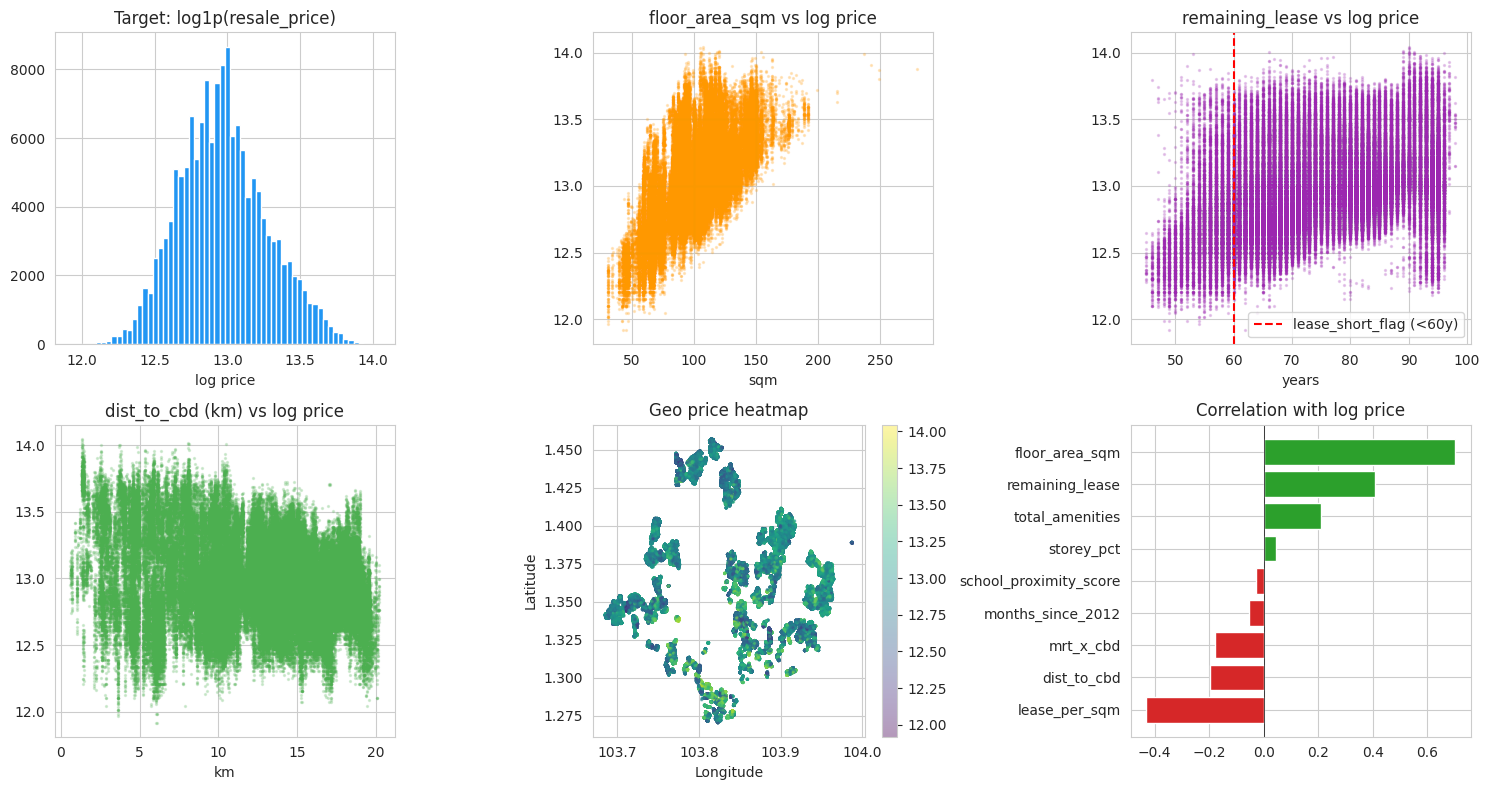

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
y_log_tr = np.log1p(train['resale_price'])

# 1. Distribution of log_price
axes[0,0].hist(y_log_tr, bins=60, color='#2196F3', edgecolor='white')
axes[0,0].set_title('Target: log1p(resale_price)'); axes[0,0].set_xlabel('log price')

# 2. floor_area vs price
axes[0,1].scatter(train['floor_area_sqm'], y_log_tr, s=2, alpha=0.2, color='#FF9800')
axes[0,1].set_title('floor_area_sqm vs log price'); axes[0,1].set_xlabel('sqm')

# 3. remaining_lease vs price (lease decay)
axes[0,2].scatter(train['remaining_lease'], y_log_tr, s=2, alpha=0.2, color='#9C27B0')
axes[0,2].axvline(60, color='red', ls='--', label='lease_short_flag (<60y)')
axes[0,2].set_title('remaining_lease vs log price'); axes[0,2].set_xlabel('years'); axes[0,2].legend()

# 4. dist_to_cbd vs price
axes[1,0].scatter(train['dist_to_cbd'], y_log_tr, s=2, alpha=0.2, color='#4CAF50')
axes[1,0].set_title('dist_to_cbd (km) vs log price'); axes[1,0].set_xlabel('km')

# 5. Geographic price scatter
sc = axes[1,1].scatter(train['Longitude'], train['Latitude'], c=y_log_tr, s=2, alpha=0.4, cmap='viridis')
axes[1,1].set_title('Geo price heatmap'); axes[1,1].set_xlabel('Longitude'); axes[1,1].set_ylabel('Latitude')
plt.colorbar(sc, ax=axes[1,1])

# 6. Correlation of new features with target
new_feats = ['floor_area_sqm','remaining_lease','dist_to_cbd','storey_pct','lease_per_sqm',
             'mrt_x_cbd','total_amenities','school_proximity_score','months_since_2012']
corrs = pd.Series({f: train[f].corr(y_log_tr) for f in new_feats}).sort_values()
axes[1,2].barh(corrs.index, corrs.values, color=['#d62728' if v<0 else '#2ca02c' for v in corrs.values])
axes[1,2].set_title('Correlation with log price'); axes[1,2].axvline(0, color='black', lw=0.5)

plt.tight_layout(); plt.show()

## 3. Lag features — town × flat_type rolling medians (v11 winner)

For each `(town, flat_type, year-month)` we compute the **count-weighted median price-per-sqm** over a trailing window (3, 6, 12 months) using *only past transactions*. The lookup is then merged onto each train row by `ym`, and onto each test row by taking the *last available* value for that `(town, flat_type)`.

**Why this works:** HDB prices have strong local temporal trends — the same flat type in TAMPINES last quarter is the single best price anchor for a sale this quarter. The 3/6/12 ladder lets the model pick the appropriate smoothing.

**Why no leakage:** the rolling window only looks at `prior['ym'] < cur_ym`, never the current month.

> 💡 **Lesson — temporal targets must look backwards only.** Any rolling stat that includes the *current* row is leakage and inflates CV. Always assert `lag.ym < target.ym` strictly.

In [7]:
t = time.time()
train['ppsm'] = train['resale_price'] / train['floor_area_sqm']
glob_ppsm     = float(train['ppsm'].median())

agg = (train.groupby(['town','flat_type_ord','ym'])['ppsm']
       .agg(['median','count']).reset_index().sort_values('ym'))

def rolling_for(g, win):
    g = g.sort_values('ym').reset_index(drop=True)
    out = np.full(len(g), np.nan)
    for i, cur_ym in enumerate(g['ym']):
        prior = g.iloc[:i]
        if len(prior) == 0:
            continue
        m = (cur_ym - prior['ym']) <= win
        if m.sum() == 0:
            continue
        out[i] = np.average(prior['median'][m], weights=prior['count'][m])
    g[f'lag_{win}m'] = out
    return g[['town','flat_type_ord','ym', f'lag_{win}m']]

lag_pieces = {3: [], 6: [], 12: []}
for _, grp in agg.groupby(['town','flat_type_ord']):
    for w in (3, 6, 12):
        lag_pieces[w].append(rolling_for(grp, w))

for w in (3, 6, 12):
    lt    = pd.concat(lag_pieces[w], ignore_index=True)
    train = train.merge(lt, on=['town','flat_type_ord','ym'], how='left').reset_index(drop=True)
    last  = (lt.sort_values('ym').dropna()
               .groupby(['town','flat_type_ord']).tail(1)
             [['town','flat_type_ord', f'lag_{w}m']])
    test  = test.merge(last, on=['town','flat_type_ord'], how='left').reset_index(drop=True)
    train[f'lag_{w}m'] = train[f'lag_{w}m'].fillna(glob_ppsm)
    test [f'lag_{w}m'] = test [f'lag_{w}m'].fillna(glob_ppsm)

for d in (train, test):
    d['price_velocity'] = (d['lag_3m'] / d['lag_12m'].replace(0, np.nan)).fillna(1.0).clip(0.5, 2.0)

y = np.log1p(train['resale_price'])
lap('lag_features', t)

  [lag_features] 18.9s


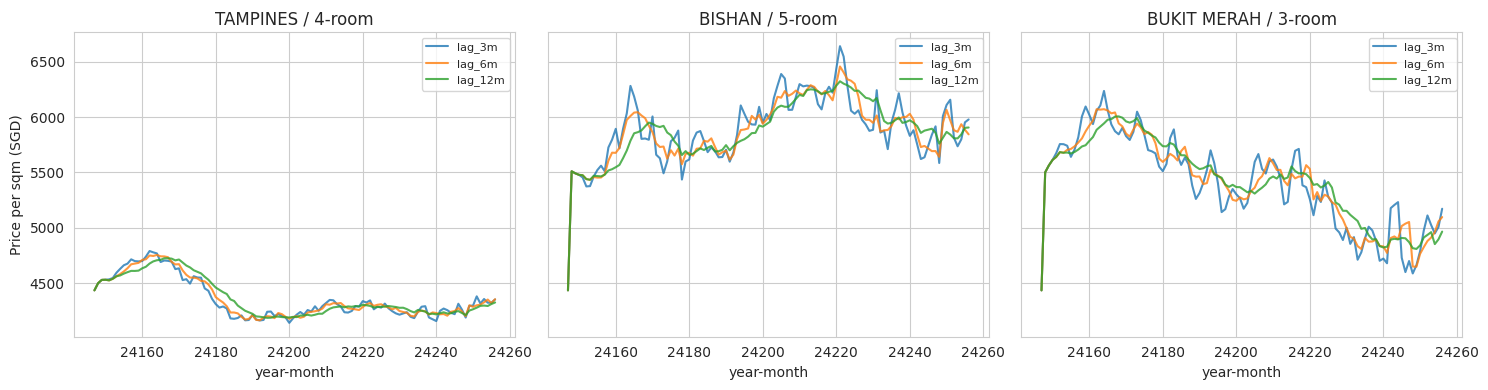

In [8]:
# Visualise lag features for 3 sample town/flat_type combos
sample_combos = [('TAMPINES', 4), ('BISHAN', 5), ('BUKIT MERAH', 3)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (tn, ft) in zip(axes, sample_combos):
    sub = train[(train['town']==tn) & (train['flat_type_ord']==ft)].sort_values('ym')
    if len(sub) == 0: continue
    ax.plot(sub['ym'], sub['lag_3m'],  label='lag_3m',  alpha=0.8)
    ax.plot(sub['ym'], sub['lag_6m'],  label='lag_6m',  alpha=0.8)
    ax.plot(sub['ym'], sub['lag_12m'], label='lag_12m', alpha=0.8)
    ax.set_title(f'{tn} / {ft}-room'); ax.set_xlabel('year-month'); ax.legend(fontsize=8)
axes[0].set_ylabel('Price per sqm (SGD)')
plt.tight_layout(); plt.show()

## 4. KNN log-price feature (v11 keeper, demoted from base)

For each train row in year `cy`, find the **20 nearest geographical neighbours among rows from prior years** (BallTree on haversine), and take the mean of their `log(price)`. For test rows, neighbours are queried from the full training set.

This was a base model in v10/v11 but the meta-learner only gave it ~0.02 weight. In v12+ we demoted it to a **feature** so the GBDTs can use it as a smooth prior alongside everything else — much higher impact than as a standalone model.

> 💡 **Lesson — features vs. bases.** Anything a meta-learner gives <0.05 weight is better expressed as a feature. Bases pay full CV cost; features ride for free on the existing trees.

In [9]:
t = time.time()
K      = 20
y_log  = y.values
yr_tr  = train['Tranc_Year'].values
lat_tr = train['Latitude'].fillna(lat_med).values
lon_tr = train['Longitude'].fillna(lon_med).values

knn_tr = np.zeros(len(train))
for cy in sorted(np.unique(yr_tr)):
    pri = yr_tr < cy
    cur = yr_tr == cy
    if pri.sum() == 0:
        knn_tr[cur] = float(np.median(y_log)); continue
    bt = BallTree(np.radians(np.column_stack([lat_tr[pri], lon_tr[pri]])), metric='haversine')
    _, idx = bt.query(np.radians(np.column_stack([lat_tr[cur], lon_tr[cur]])), k=min(K, pri.sum()))
    knn_tr[cur] = y_log[pri][idx].mean(axis=1)
train['knn_logprice'] = knn_tr

bt_all = BallTree(np.radians(np.column_stack([lat_tr, lon_tr])), metric='haversine')
lat_te = test['Latitude'].fillna(lat_med).values
lon_te = test['Longitude'].fillna(lon_med).values
_, idx_te = bt_all.query(np.radians(np.column_stack([lat_te, lon_te])), k=K)
test['knn_logprice'] = y_log[idx_te].mean(axis=1)
lap('knn_feature', t)

  [knn_feature] 7.4s


## 5. Bayesian smoothed target encoding (v4/v7 winner)

For each categorical key, replace the level with a smoothed mean of the target:

`enc = (sum_y + global_mean × smooth) / (count + smooth)`

with `smooth=20`. Computed via 5-fold OOF on train (so each train row is encoded by a fold that didn't see it) and the full-data fit applied to test.

**Encoded keys:**
- `town` (low cardinality, captures macro level)
- `flat_model` (medium cardinality, captures unit type)
- `town × flat_type` crossed (v8 winner — captures town-specific premiums per flat size)

**Explicitly dropped:** `address`, `block_enc`, `price_tier_enc` — high-cardinality TE proven to dominate trees and overfit (v8/v13). v15 also drops `price_tier_enc` because `geo_cluster` is already a column.

> 💡 **Lesson — smoothing parameter matters.** With `smooth=0` you overfit rare levels (a town with 2 sales gets the mean of those 2). With `smooth=∞` everything collapses to the global mean. `smooth=20` is roughly "trust this category once it has 20 sales."

> 💡 **Lesson — beware redundant encodings.** If a feature appears as a raw column, an OHE column, *and* a target encoding, you triple-count it. Trees handle this OK; linear meta-learners do not.

In [10]:
t = time.time()
SMOOTH    = 20
y_arr     = y.reset_index(drop=True)
kf_te     = KFold(n_splits=5, shuffle=True, random_state=42)

def kfold_target_encode(train_key, test_key, y_arr, smooth, kf):
    train_key = pd.Series(train_key).astype(str).reset_index(drop=True)
    test_key  = pd.Series(test_key ).astype(str).reset_index(drop=True)
    gm        = float(y_arr.mean())
    oof       = np.full(len(train_key), gm)
    for tr_ix, va_ix in kf.split(train_key):
        s  = pd.DataFrame({'k': train_key.iloc[tr_ix].values, 'y': y_arr.iloc[tr_ix].values})
        g  = s.groupby('k')['y'].agg(['sum','count'])
        sm = (g['sum'] + gm * smooth) / (g['count'] + smooth)
        oof[va_ix] = train_key.iloc[va_ix].map(sm).fillna(gm).values
    g_full = (pd.DataFrame({'k': train_key.values, 'y': y_arr.values})
              .groupby('k')['y'].agg(['sum','count']))
    sm_full  = (g_full['sum'] + gm * smooth) / (g_full['count'] + smooth)
    test_enc = test_key.map(sm_full).fillna(gm).values
    return oof, test_enc

train['te_town'],      test['te_town']      = kfold_target_encode(train['town'],       test['town'],       y_arr, SMOOTH, kf_te)
train['te_flatmodel'], test['te_flatmodel'] = kfold_target_encode(train['flat_model'], test['flat_model'], y_arr, SMOOTH, kf_te)
train['te_town_type'], test['te_town_type'] = kfold_target_encode(
    train['town'].astype(str)+'_'+train['flat_type'].astype(str),
    test ['town'].astype(str)+'_'+test ['flat_type'].astype(str),
    y_arr, SMOOTH, kf_te)

# v15: price_tier_enc removed — redundant with geo_cluster + te_town

lap('target_encoding', t)
for c in ['te_town','te_flatmodel','te_town_type']:
    print(f"  {c:<16}  NaN tr={np.isnan(train[c]).sum()}  te={np.isnan(test[c]).sum()}")

  [target_encoding] 0.4s
  te_town           NaN tr=0  te=0
  te_flatmodel      NaN tr=0  te=0
  te_town_type      NaN tr=0  te=0


## 6. PCA amenity components (v7 winner)

We have 10 amenity-distance/score columns. They are mutually correlated (a unit close to MRT tends to be close to malls and hawkers). PCA(3) compresses them into 3 orthogonal components capturing ~55% variance.

**Why include both raw + PCA:** trees can use raw distances for hard splits; the PCA components give a smooth "overall amenity richness" signal that helps generalisation. Stacking redundant representations is fine for tree models.

> 💡 **Lesson — PCA is most useful when features are correlated *and* you suspect noise.** It denoises by projecting onto the dominant variance directions. Variance explained <60% on 3 components means there's still meaningful info in the rest — that's why we keep raw columns too.

In [11]:
t = time.time()
AMENITY_COLS = ['Mall_Nearest_Distance','Hawker_Nearest_Distance','mrt_nearest_distance',
                'bus_stop_nearest_distance','pri_sch_nearest_distance','sec_sch_nearest_dist',
                'mall_score','hawker_score','total_amenities','school_proximity_score']

amen_tr = train[AMENITY_COLS].copy()
amen_te = test [AMENITY_COLS].copy()
for c in AMENITY_COLS:
    med = float(amen_tr[c].median())
    amen_tr[c] = amen_tr[c].fillna(med)
    amen_te[c] = amen_te[c].fillna(med)

sc_amen = StandardScaler().fit(amen_tr)
pca = PCA(n_components=3, random_state=42).fit(sc_amen.transform(amen_tr))
amen_pc_tr = pca.transform(sc_amen.transform(amen_tr))
amen_pc_te = pca.transform(sc_amen.transform(amen_te))
for i in range(3):
    train[f'amen_pc{i+1}'] = amen_pc_tr[:, i]
    test [f'amen_pc{i+1}'] = amen_pc_te[:, i]
print(f"PCA explained variance: {pca.explained_variance_ratio_.round(3)} (sum={pca.explained_variance_ratio_.sum():.3f})")
lap('pca_amenity', t)

PCA explained variance: [0.251 0.184 0.116] (sum=0.551)
  [pca_amenity] 0.1s


## 7. Feature matrix

Two parallel matrices are built:

- **`X_lgb`** — keeps `town`, `flat_model`, `planning_area` as **pandas categoricals**. LightGBM handles them natively (faster, often better than OHE for high-cardinality).
- **`X_dense`** — one-hot encoded categoricals concatenated with numerics, then standardised. Used by XGBoost and any sklearn-API model.

> 💡 **Lesson — let the model see categoricals natively when it can.** LightGBM/CatBoost categorical handling beats OHE on high-cardinality features. OHE explodes the matrix and dilutes split candidates.

In [12]:
CAT_COLS = ['town','flat_model','planning_area']

NUM_COLS = [
    # Core property
    'floor_area_sqm','floor_area_sq','log_floor_area',
    'mid_storey','max_floor_lvl','storey_pct','units_per_floor',
    'year_completed','total_dwelling_units','flat_type_ord',
    # Lease (v6/v7 stack)
    'age_when_sold','remaining_lease','lease_log','lease_short_flag','lease_value','lease_per_sqm',
    # Geo (v2 stack)
    'Latitude','Longitude','dist_to_cbd','geo_cluster',
    # Amenities
    'Mall_Nearest_Distance','mall_score',
    'Hawker_Nearest_Distance','hawker_score',
    'hawker_food_stalls','hawker_market_stalls','total_amenities',
    'mrt_nearest_distance','bus_interchange','mrt_interchange','bus_stop_nearest_distance','mrt_x_cbd',
    'pri_sch_nearest_distance','vacancy','pri_sch_affiliation',
    'sec_sch_nearest_dist','cutoff_point','affiliation','school_proximity_score',
    'amen_pc1','amen_pc2','amen_pc3',
    # Block features
    'residential','commercial','market_hawker','multistorey_carpark','precinct_pavilion',
    '1room_sold','2room_sold','3room_sold','4room_sold','5room_sold',
    'exec_sold','multigen_sold','studio_apartment_sold',
    '1room_rental','2room_rental','3room_rental','other_room_rental',
    # Time
    'Tranc_Year','Tranc_Month','month_sin','month_cos','ym','months_since_2012',
    # Lag (v11 winner)
    'lag_3m','lag_6m','lag_12m','price_velocity',
    # KNN feature (v11 keeper)
    'knn_logprice',
    # Target encoding (v15: dropped price_tier_enc — redundant with geo_cluster + te_town)
    'te_town','te_flatmodel','te_town_type',
]

for c in CAT_COLS:
    train[c] = train[c].astype('category')
    test [c] = pd.Categorical(test[c], categories=train[c].cat.categories)

X_lgb = train[NUM_COLS + CAT_COLS].copy()
T_lgb = test [NUM_COLS + CAT_COLS].copy()
for c in NUM_COLS:
    med = float(pd.to_numeric(X_lgb[c], errors='coerce').median())
    X_lgb[c] = pd.to_numeric(X_lgb[c], errors='coerce').fillna(med)
    T_lgb[c] = pd.to_numeric(T_lgb[c], errors='coerce').fillna(med)

ohe    = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_tr = ohe.fit_transform(train[CAT_COLS])
ohe_te = ohe.transform(test [CAT_COLS])
X_dense = np.hstack([X_lgb[NUM_COLS].values, ohe_tr])
T_dense = np.hstack([T_lgb[NUM_COLS].values, ohe_te])

sc      = StandardScaler()
X_lin_s = sc.fit_transform(X_dense)
T_lin_s = sc.transform(T_dense)

print(f"X_lgb={X_lgb.shape}  X_dense={X_dense.shape}  T_lgb={T_lgb.shape}")

X_lgb=(150634, 76)  X_dense=(150634, 151)  T_lgb=(16737, 76)


## 8. CV folds — random KFold (leaderboard-aligned)

Random 5-fold KFold matches Kaggle leaderboard scoring (test set is i.i.d. sampled from the full population). Walk-forward CV would be more realistic for *future* predictions but penalises us at scoring time, so v15 doesn't run it.

> 💡 **Lesson — your CV scheme must mirror your test scheme.** Walk-forward is the right answer if the model will be deployed *forward in time*. For a Kaggle leaderboard with random hold-out, random KFold is correct. v12/v13 used WF and bled $1k+ to leaderboard ranking — honest CV but wrong objective.

In [13]:
kf       = KFold(n_splits=5, shuffle=True, random_state=42)
folds    = list(kf.split(X_lgb))
for i, (tr, va) in enumerate(folds):
    print(f"  fold{i}  n_tr={len(tr):,}  n_va={len(va):,}")

  fold0  n_tr=120,507  n_va=30,127
  fold1  n_tr=120,507  n_va=30,127
  fold2  n_tr=120,507  n_va=30,127
  fold3  n_tr=120,507  n_va=30,127
  fold4  n_tr=120,508  n_va=30,126


## 9. Base A — LightGBM with Huber loss (3-seed average)

**Loss function:** Huber, `alpha=0.9`. Behaves like MSE near the centre and like MAE in the tails — robust to luxury-unit outliers (HDB resale prices range from $150k to $1.26M; the top 1% can dominate squared-error gradients).

**Seed averaging:** train 3 models with seeds `[42, 7, 2024]` and average their predictions per fold. Reduces variance from random feature/row sampling at near-zero cost beyond compute.

**Early stopping:** `early_stopping(80)` on the validation fold, `n_estimators=3000` upper bound. Refit uses the average best iteration.

> 💡 **Lesson — Huber + seeds is a cheap robustness pair.** When the target has a fat tail (like prices), Huber stops the few mega-units from owning the loss. Seed averaging is one line of code that buys you ~$50–100 RMSE for free.

In [14]:
LGB_HUBER_PARAMS = dict(
    objective='huber', alpha=0.9, metric='rmse',
    n_estimators=3000, learning_rate=0.03,
    num_leaves=63, min_child_samples=20,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=1,
    reg_alpha=0.1, reg_lambda=1.0,
    verbose=-1, n_jobs=-1,
)
SEEDS = [42, 7, 2024]

t = time.time()
lgbh_oof   = np.full(len(train), 0.0)
lgbh_iters = []
for i, (tr_ix, va_ix) in enumerate(folds):
    fold_pred = np.zeros(len(va_ix))
    iters = []
    for sd in SEEDS:
        m = lgb.LGBMRegressor(**LGB_HUBER_PARAMS, random_state=sd)
        m.fit(X_lgb.iloc[tr_ix], y.iloc[tr_ix],
              eval_set=[(X_lgb.iloc[va_ix], y.iloc[va_ix])],
              categorical_feature=CAT_COLS,
              callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(period=0)])
        iters.append(m.best_iteration_)
        fold_pred += m.predict(X_lgb.iloc[va_ix]) / len(SEEDS)
    lgbh_oof[va_ix] = fold_pred
    lgbh_iters.append(int(np.mean(iters)))
    print(f"  fold{i}  iters={iters}  log={rmse_log(y.iloc[va_ix], fold_pred):.4f}  sgd=${rmse_sgd(y.iloc[va_ix], fold_pred):,.0f}")

print(f"\nLGBM-Huber (seed-avg) CV  log={rmse_log(y, lgbh_oof):.4f}  sgd=${rmse_sgd(y, lgbh_oof):,.0f}")
lgbh_avg_iter = int(np.mean(lgbh_iters))
lap('lgb_huber', t)

  fold0  iters=[2997, 3000, 2995]  log=0.0474  sgd=$21,655
  fold1  iters=[2996, 3000, 3000]  log=0.0483  sgd=$22,570
  fold2  iters=[3000, 2990, 3000]  log=0.0475  sgd=$21,994
  fold3  iters=[2999, 2997, 3000]  log=0.0475  sgd=$22,101
  fold4  iters=[3000, 2997, 3000]  log=0.0477  sgd=$21,881

LGBM-Huber (seed-avg) CV  log=0.0477  sgd=$22,042
  [lgb_huber] 957.4s


## 10. Base B — LightGBM with MSE loss (3-seed average)

Same architecture as Base A but `objective='regression'` (MSE) and `num_leaves=127` (deeper trees). Pairs naturally with Huber — together they bracket the loss landscape: Huber pulls the model toward the bulk, MSE chases the tails.

> 💡 **Lesson — same family, different loss = useful diversity.** You don't need different model classes to get stack lift; two LGBMs with Huber vs MSE losses already de-correlate their errors enough for the meta-learner to combine them productively.

In [15]:
LGB_MSE_PARAMS = dict(
    objective='regression', metric='rmse',
    n_estimators=3000, learning_rate=0.03,
    num_leaves=127, min_child_samples=20,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=1,
    reg_alpha=0.1, reg_lambda=1.0,
    verbose=-1, n_jobs=-1,
)

t = time.time()
lgbm_oof   = np.full(len(train), 0.0)
lgbm_iters = []
for i, (tr_ix, va_ix) in enumerate(folds):
    fold_pred = np.zeros(len(va_ix))
    iters = []
    for sd in SEEDS:
        m = lgb.LGBMRegressor(**LGB_MSE_PARAMS, random_state=sd)
        m.fit(X_lgb.iloc[tr_ix], y.iloc[tr_ix],
              eval_set=[(X_lgb.iloc[va_ix], y.iloc[va_ix])],
              categorical_feature=CAT_COLS,
              callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(period=0)])
        iters.append(m.best_iteration_)
        fold_pred += m.predict(X_lgb.iloc[va_ix]) / len(SEEDS)
    lgbm_oof[va_ix] = fold_pred
    lgbm_iters.append(int(np.mean(iters)))
    print(f"  fold{i}  iters={iters}  log={rmse_log(y.iloc[va_ix], fold_pred):.4f}  sgd=${rmse_sgd(y.iloc[va_ix], fold_pred):,.0f}")

print(f"\nLGBM-MSE (seed-avg) CV  log={rmse_log(y, lgbm_oof):.4f}  sgd=${rmse_sgd(y, lgbm_oof):,.0f}")
lgbm_avg_iter = int(np.mean(lgbm_iters))
lap('lgb_mse', t)

  fold0  iters=[2004, 2274, 2037]  log=0.0474  sgd=$21,622
  fold1  iters=[2106, 2192, 2194]  log=0.0483  sgd=$22,536
  fold2  iters=[2332, 2261, 2323]  log=0.0474  sgd=$21,982
  fold3  iters=[2315, 2404, 2184]  log=0.0475  sgd=$22,104
  fold4  iters=[2266, 2178, 2157]  log=0.0476  sgd=$21,806

LGBM-MSE (seed-avg) CV  log=0.0477  sgd=$22,012
  [lgb_mse] 1028.3s


## 11. Base C — XGBoost (level-wise GBDT)

**Architectural difference vs LightGBM:** XGBoost grows trees **level-wise** (all nodes at depth `d` before going to `d+1`); LightGBM grows **leaf-wise** (always split the leaf with the highest gain). Different structural bias → different errors → genuine stack diversity.

Same features (`X_dense`, OHE-encoded), `max_depth=7`, `min_child_weight=10`.

> 💡 **Lesson — diversity comes from algorithmic difference, not hyperparameter tweaks.** Two LGBMs with different `num_leaves` are still highly correlated. LGBM vs XGBoost gives the meta-learner something genuinely orthogonal to combine.

In [16]:
XGB_PARAMS = dict(
    objective='reg:squarederror', eval_metric='rmse',
    n_estimators=3000, learning_rate=0.03,
    max_depth=7, min_child_weight=10,
    subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.1, reg_lambda=1.0,
    tree_method='hist', device='cpu',
    verbosity=0, n_jobs=-1, random_state=42,
    early_stopping_rounds=80,
)

t = time.time()
xgb_oof   = np.full(len(train), 0.0)
xgb_iters = []
for i, (tr_ix, va_ix) in enumerate(folds):
    m = xgb.XGBRegressor(**XGB_PARAMS)
    m.fit(X_dense[tr_ix], y.iloc[tr_ix].values,
          eval_set=[(X_dense[va_ix], y.iloc[va_ix].values)],
          verbose=False)
    pred_va = m.predict(X_dense[va_ix])
    xgb_oof[va_ix] = pred_va
    xgb_iters.append(m.best_iteration)
    print(f"  fold{i}  iter={m.best_iteration}  log={rmse_log(y.iloc[va_ix], pred_va):.4f}  sgd=${rmse_sgd(y.iloc[va_ix], pred_va):,.0f}")

print(f"\nXGBoost CV  log={rmse_log(y, xgb_oof):.4f}  sgd=${rmse_sgd(y, xgb_oof):,.0f}")
xgb_avg_iter = int(round(np.mean(xgb_iters)))
lap('xgb', t)

  fold0  iter=2999  log=0.0482  sgd=$22,035
  fold1  iter=2878  log=0.0489  sgd=$22,842
  fold2  iter=2998  log=0.0480  sgd=$22,352
  fold3  iter=2992  log=0.0480  sgd=$22,513
  fold4  iter=2999  log=0.0484  sgd=$22,607

XGBoost CV  log=0.0483  sgd=$22,472
  [xgb] 549.1s


## 12. Base D — Per-segment LGBM blend (specialist)

Train **one LGBM per `flat_type_ord` value** (1-room through multi-generation). Each segment-model only sees its own segment's data, so it can specialise on the price dynamics of (say) 1-room rentals without being pulled around by 5-room executive flats.

**Backstop:** if a segment has <100 train rows or zero validation rows in a fold, fall back to the global LGBM-MSE OOF prediction.

This was Base F in v14; renumbered to Base D in v15 after dropping RF + HGBT.

> 💡 **Lesson — when error patterns are heterogeneous across a discrete attribute, specialise.** A single global model averages its mistakes across segments. Per-segment models often gain more from specialisation than they lose from smaller training sets.

In [17]:
SEG_COL = 'flat_type_ord'
SEG_LGB_PARAMS = dict(
    objective='regression', metric='rmse',
    n_estimators=2000, learning_rate=0.04,
    num_leaves=63, min_child_samples=15,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=1,
    reg_alpha=0.1, reg_lambda=1.0,
    verbose=-1, n_jobs=-1, random_state=42,
)

t = time.time()
seg_oof = np.full(len(train), 0.0)
seg_arr = train[SEG_COL].values
for i, (tr_ix, va_ix) in enumerate(folds):
    pred_va = np.zeros(len(va_ix))
    for seg in np.unique(seg_arr):
        seg_tr = tr_ix[seg_arr[tr_ix] == seg]
        seg_va_mask = (seg_arr[va_ix] == seg)
        if len(seg_tr) < 100 or seg_va_mask.sum() == 0:
            # too few samples for segment model — fall back to global (filled later by stack meta)
            continue
        seg_va_global = va_ix[seg_va_mask]
        m = lgb.LGBMRegressor(**SEG_LGB_PARAMS)
        m.fit(X_lgb.iloc[seg_tr], y.iloc[seg_tr],
              eval_set=[(X_lgb.iloc[seg_va_global], y.iloc[seg_va_global])],
              categorical_feature=CAT_COLS,
              callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(period=0)])
        pred_va[seg_va_mask] = m.predict(X_lgb.iloc[seg_va_global])
    # Fill any zero predictions (segment too small) with the LGBM-MSE OOF as backstop
    zero_mask = pred_va == 0
    if zero_mask.any():
        pred_va[zero_mask] = lgbm_oof[va_ix][zero_mask]
    seg_oof[va_ix] = pred_va
    print(f"  fold{i}  log={rmse_log(y.iloc[va_ix], pred_va):.4f}  sgd=${rmse_sgd(y.iloc[va_ix], pred_va):,.0f}")

print(f"\nSegment-blend CV  log={rmse_log(y, seg_oof):.4f}  sgd=${rmse_sgd(y, seg_oof):,.0f}")
lap('seg_blend', t)

  fold0  log=0.0481  sgd=$21,939
  fold1  log=0.0491  sgd=$22,997
  fold2  log=0.0481  sgd=$22,355
  fold3  log=0.0480  sgd=$22,352
  fold4  log=0.0483  sgd=$22,236

Segment-blend CV  log=0.0483  sgd=$22,379
  [seg_blend] 215.8s


### Visualisation — base CV diagnostics

Two checks before stacking:
1. **Per-base RMSE** — each base on its own.
2. **OOF correlation matrix** — how independent are the bases' errors? Stacking lift is roughly proportional to `(1 - max_correlation)`. Two bases at ρ=0.999 give the meta-learner almost nothing.

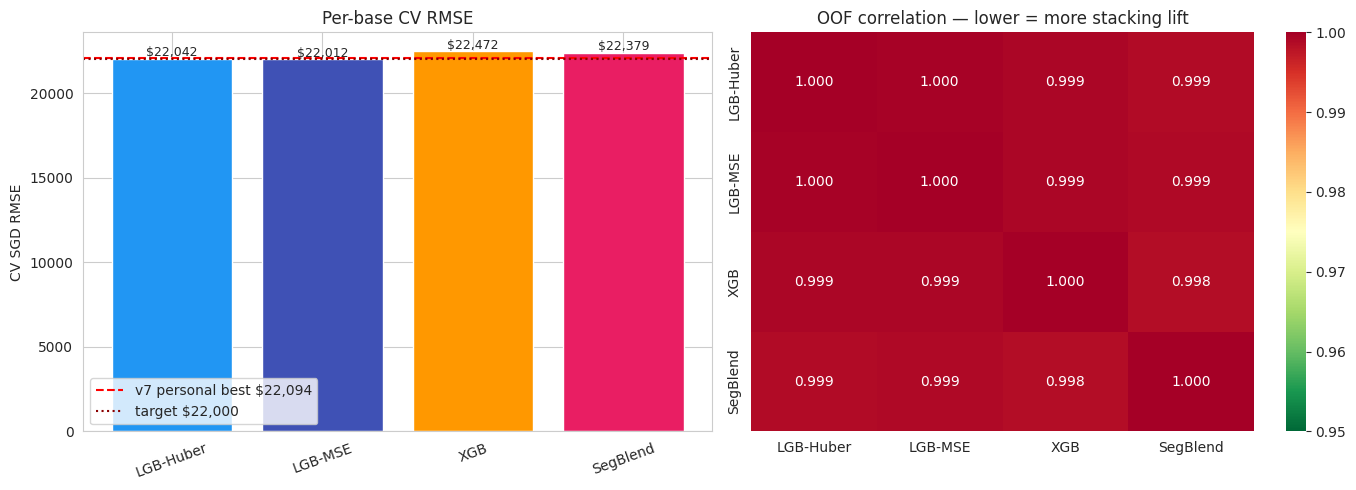


Interpretation: when two bases hit ~1.000 correlation, the meta-learner can't
extract independent information from them. The XGB column should show lower
correlation with the LGBM bases (different split algorithm) — that's where the lift comes from.


In [18]:
base_names = ['LGB-Huber','LGB-MSE','XGB','SegBlend']
oof_dict   = {'LGB-Huber': lgbh_oof, 'LGB-MSE': lgbm_oof, 'XGB': xgb_oof, 'SegBlend': seg_oof}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: SGD RMSE per base
vals = [rmse_sgd(y, oof_dict[n]) for n in base_names]
bars = axes[0].bar(base_names, vals, color=['#2196F3','#3F51B5','#FF9800','#E91E63'])
axes[0].axhline(22094, color='red', ls='--', label='v7 personal best $22,094')
axes[0].axhline(22000, color='darkred', ls=':', label='target $22,000')
for b, v in zip(bars, vals):
    axes[0].text(b.get_x()+b.get_width()/2, v+150, f'${v:,.0f}', ha='center', fontsize=9)
axes[0].set_ylabel('CV SGD RMSE'); axes[0].set_title('Per-base CV RMSE'); axes[0].legend()
axes[0].tick_params(axis='x', rotation=20)

# Heatmap: OOF correlation — lower correlation = more stack lift
oof_mat_full = np.column_stack([oof_dict[n] for n in base_names])
corr = pd.DataFrame(np.corrcoef(oof_mat_full.T), index=base_names, columns=base_names)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0.95, vmax=1.0, ax=axes[1])
axes[1].set_title('OOF correlation — lower = more stacking lift')
plt.tight_layout(); plt.show()

print("\nInterpretation: when two bases hit ~1.000 correlation, the meta-learner can't")
print("extract independent information from them. The XGB column should show lower")
print("correlation with the LGBM bases (different split algorithm) — that's where the lift comes from.")

## 13. Stacking — non-negative LinearRegression on KFold OOF

The meta-learner sees 4 columns of out-of-fold predictions and learns a non-negative linear combination of them. Constraints:

- **Non-negative weights** (`positive=True`) — prevents the meta from giving a base a negative weight, which is rarely meaningful and often a sign of overfitting on the meta layer.
- **Trained on OOF only** — bases never saw their own validation rows, so the meta sees genuine out-of-sample errors.
- **Inner KFold for stack RMSE** — we re-fold the OOF matrix to estimate the stack's own generalisation error honestly.

> 💡 **Lesson — stacking is just a weighted vote, but the votes must be honest.** If you train the meta on in-fold predictions, you've leaked the validation labels into the meta and your CV will look great while leaderboard tanks.

In [19]:
oof_mat = np.column_stack([oof_dict[n] for n in base_names])
y_arr   = y.values

print('Base CV RMSE:')
for n in base_names:
    print(f"  {n:<10}  log={rmse_log(y_arr, oof_dict[n]):.4f}  sgd=${rmse_sgd(y_arr, oof_dict[n]):,.0f}")

# Inner KFold on OOF for honest stack RMSE
kf_meta = KFold(n_splits=5, shuffle=True, random_state=0)
stack_oof = np.zeros(len(y_arr))
for tr_ix, va_ix in kf_meta.split(oof_mat):
    mm = LinearRegression(positive=True)
    mm.fit(oof_mat[tr_ix], y_arr[tr_ix])
    stack_oof[va_ix] = mm.predict(oof_mat[va_ix])

print(f"\nStack CV  log={rmse_log(y_arr, stack_oof):.4f}  sgd=${rmse_sgd(y_arr, stack_oof):,.0f}")

meta = LinearRegression(positive=True)
meta.fit(oof_mat, y_arr)
print(f"\nMeta weights:")
for n, w in zip(base_names, meta.coef_):
    print(f"  {n:<10}  {w:.4f}")
print(f"  intercept   {meta.intercept_:.4f}")

Base CV RMSE:
  LGB-Huber   log=0.0477  sgd=$22,042
  LGB-MSE     log=0.0477  sgd=$22,012
  XGB         log=0.0483  sgd=$22,472
  SegBlend    log=0.0483  sgd=$22,379

Stack CV  log=0.0473  sgd=$21,832

Meta weights:
  LGB-Huber   0.3251
  LGB-MSE     0.2322
  XGB         0.1349
  SegBlend    0.3094
  intercept   -0.0196


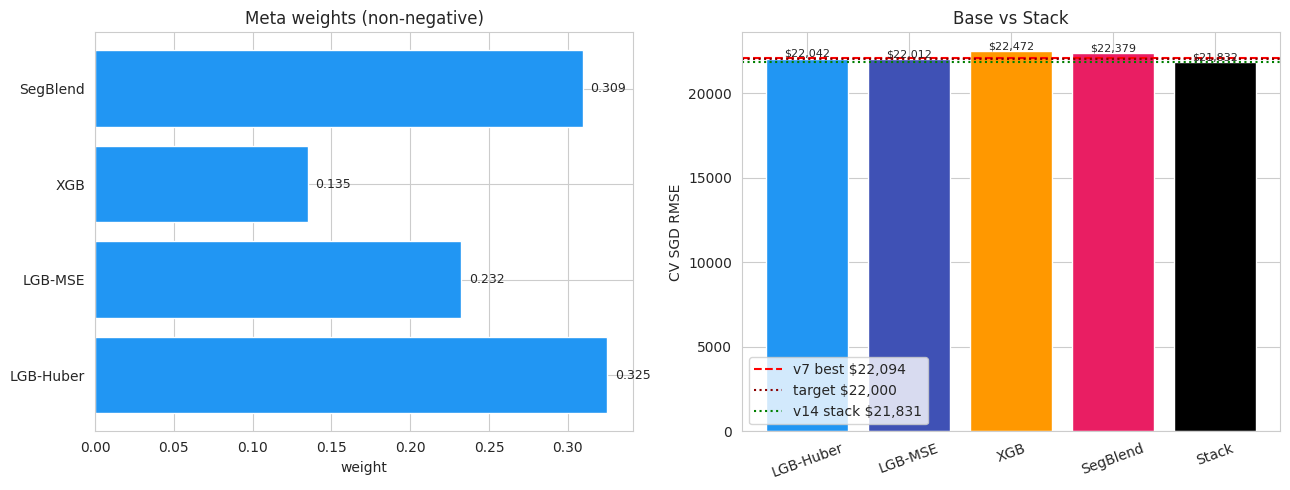

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Meta weights
weights = meta.coef_
axes[0].barh(base_names, weights, color='#2196F3')
for i, w in enumerate(weights):
    axes[0].text(w+0.005, i, f'{w:.3f}', va='center', fontsize=9)
axes[0].set_title('Meta weights (non-negative)'); axes[0].set_xlabel('weight')

# Bar: base+stack SGD
labels   = base_names + ['Stack']
sgd_vals = [rmse_sgd(y_arr, oof_dict[n]) for n in base_names] + [rmse_sgd(y_arr, stack_oof)]
colors   = ['#2196F3','#3F51B5','#FF9800','#E91E63','#000']
bars = axes[1].bar(labels, sgd_vals, color=colors)
axes[1].axhline(22094, color='red', ls='--', label='v7 best $22,094')
axes[1].axhline(22000, color='darkred', ls=':', label='target $22,000')
axes[1].axhline(21831, color='green', ls=':', label='v14 stack $21,831')
for b, v in zip(bars, sgd_vals):
    axes[1].text(b.get_x()+b.get_width()/2, v+100, f'${v:,.0f}', ha='center', fontsize=8)
axes[1].set_ylabel('CV SGD RMSE'); axes[1].set_title('Base vs Stack')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

### Visualisation — LightGBM feature importance

Quick proxy: refit one LGBM-MSE on the **last fold's training rows** (~120k) using the CV-derived best iteration count, then read `feature_importances_` (gain). This shows which features the trees actually rely on for splits — a sanity check that the engineered features (lag, KNN, target encodings) earn their weight versus raw columns.

> 💡 **Lesson — feature importance ≠ causal effect.** A high-gain feature is one the trees split on often; it may be acting as a proxy for something else (e.g. `knn_logprice` correlates with location, lease, *and* size). Use importance to detect dead features, not to make causal claims.

  [feat_importance_fit] 74.1s


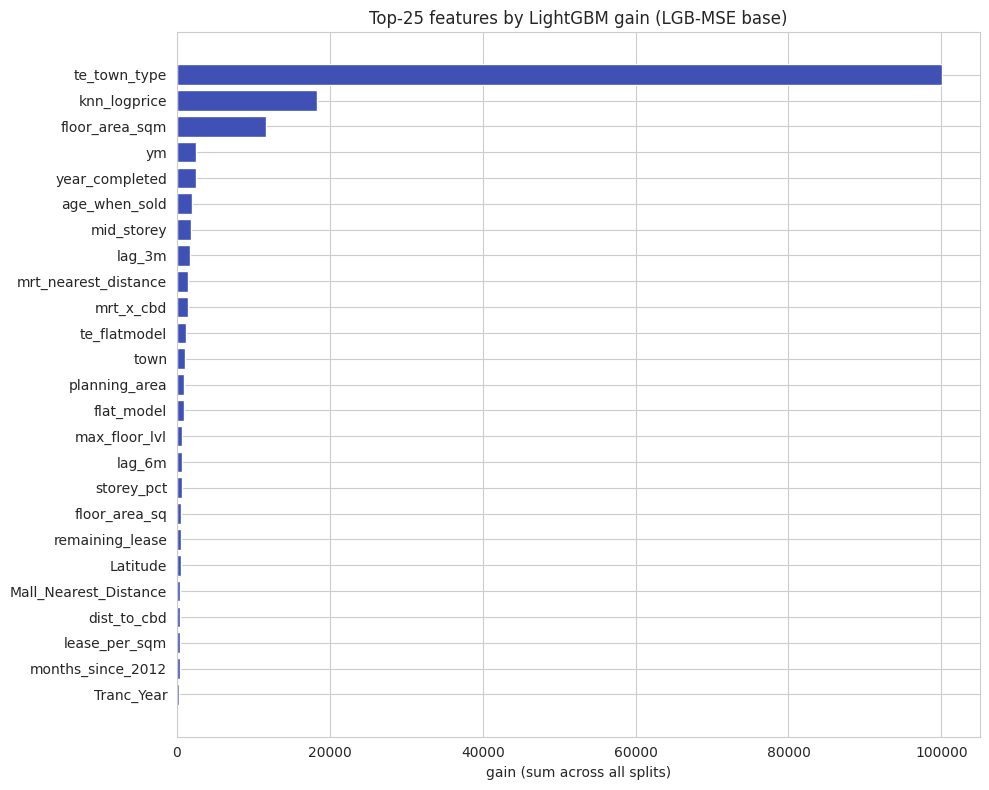


Bottom-10 (candidates for future pruning):
            feature     gain  split
        lease_value 0.138275     17
       1room_rental 0.053036      6
multistorey_carpark 0.008743      2
      multigen_sold 0.008521      1
        residential 0.000000      0
   lease_short_flag 0.000000      0
  other_room_rental 0.000000      0
         1room_sold 0.000000      0
      market_hawker 0.000000      0
  precinct_pavilion 0.000000      0


In [28]:
t = time.time()
tr_ix_last, _ = folds[-1]
fi_model = lgb.LGBMRegressor(**{k: v for k, v in LGB_MSE_PARAMS.items() if k != 'n_estimators'},
                              random_state=42, n_estimators=lgbm_avg_iter)
fi_model.fit(X_lgb.iloc[tr_ix_last], y.iloc[tr_ix_last], categorical_feature=CAT_COLS)
lap('feat_importance_fit', t)

fi = pd.DataFrame({
    'feature': X_lgb.columns,
    'gain':    fi_model.booster_.feature_importance(importance_type='gain'),
    'split':   fi_model.booster_.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False).reset_index(drop=True)

top = fi.head(25)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top['feature'][::-1], top['gain'][::-1], color='#3F51B5')
ax.set_title('Top-25 features by LightGBM gain (LGB-MSE base)')
ax.set_xlabel('gain (sum across all splits)')
plt.tight_layout(); plt.show()

print("\nBottom-10 (candidates for future pruning):")
print(fi.tail(10).to_string(index=False))

## 14. Diagnostics — where does the model still fail?

Three views into the residuals:
1. **Per-decile RMSE** — does error scale with price? (Almost always yes, in absolute SGD terms.)
2. **Actual vs predicted scatter** — does the line bend at the high end? (A sign of mean-reversion bias.)
3. **Residual scatter** — heteroscedasticity check.

> 💡 **Lesson — global RMSE hides everything.** A model with $21k RMSE might be at $10k on cheap flats and $40k on luxury units. Always slice by price decile and by segment before declaring victory.

In [29]:
preds_sgd = np.expm1(stack_oof)
true_sgd  = np.expm1(y_arr)
deciles   = pd.qcut(true_sgd, 10, labels=False)
rows = []
for d in range(10):
    mk = deciles == d
    if not mk.any(): continue
    r = float(np.sqrt(mean_squared_error(true_sgd[mk], preds_sgd[mk])))
    p = float(np.mean(np.abs(true_sgd[mk]-preds_sgd[mk])/true_sgd[mk])*100)
    rows.append([d+1, f"${true_sgd[mk].min():,.0f}–${true_sgd[mk].max():,.0f}",
                 int(mk.sum()), f"${r:,.0f}", f"{p:.1f}%"])
decile_df = pd.DataFrame(rows, columns=['Decile','Range','N','RMSE','MAPE'])
print(decile_df.to_string(index=False))

 Decile               Range     N    RMSE MAPE
      1   $150,000–$295,000 15738 $15,544 4.4%
      2   $295,088–$330,000 14995 $16,025 3.8%
      3   $330,500–$362,000 14649 $16,332 3.5%
      4   $362,500–$392,000 14877 $17,357 3.5%
      5   $392,005–$420,000 15110 $17,955 3.3%
      6   $420,001–$452,000 15113 $19,637 3.2%
      7   $452,088–$493,000 15000 $20,257 3.2%
      8   $493,001–$550,000 15430 $23,689 3.4%
      9   $550,500–$650,000 15000 $27,989 3.5%
     10 $650,021–$1,258,000 14722 $35,443 3.4%


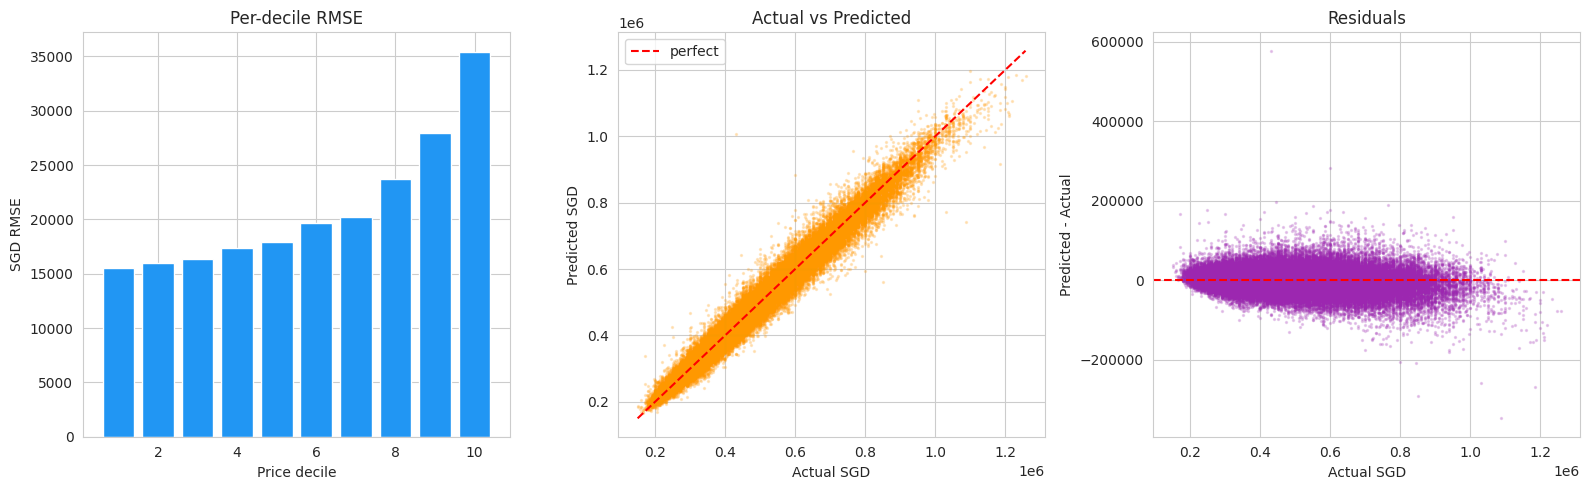

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Per-decile RMSE
rmse_by_dec = [float(d.replace('$','').replace(',','')) for d in decile_df['RMSE']]
axes[0].bar(decile_df['Decile'], rmse_by_dec, color='#2196F3')
axes[0].set_xlabel('Price decile'); axes[0].set_ylabel('SGD RMSE'); axes[0].set_title('Per-decile RMSE')

# Actual vs predicted
axes[1].scatter(true_sgd, preds_sgd, s=2, alpha=0.2, color='#FF9800')
lims = [true_sgd.min(), true_sgd.max()]
axes[1].plot(lims, lims, 'r--', label='perfect')
axes[1].set_xlabel('Actual SGD'); axes[1].set_ylabel('Predicted SGD'); axes[1].set_title('Actual vs Predicted')
axes[1].legend()

# Residual scatter
resid = preds_sgd - true_sgd
axes[2].scatter(true_sgd, resid, s=2, alpha=0.2, color='#9C27B0')
axes[2].axhline(0, color='red', ls='--')
axes[2].set_xlabel('Actual SGD'); axes[2].set_ylabel('Predicted - Actual'); axes[2].set_title('Residuals')

plt.tight_layout(); plt.show()

### Visualisation — residuals by flat type and by year

Two more slices to expose model weaknesses the global RMSE hides:

1. **Residual distribution by `flat_type_ord`** — does the model systematically over- or under-price certain flat types? A non-zero median per segment signals bias the SegBlend base should ideally absorb.
2. **RMSE by transaction year** — random KFold mixes years freely, but the model's accuracy may still drift across time. This plot makes the temporal-stability question visible without running a separate walk-forward CV.

> 💡 **Lesson — ablate by every categorical you have.** Per-segment, per-year, per-decile slices are cheap and routinely surface bugs (label leakage in one segment, a year with bad data, a flat type with too few samples).

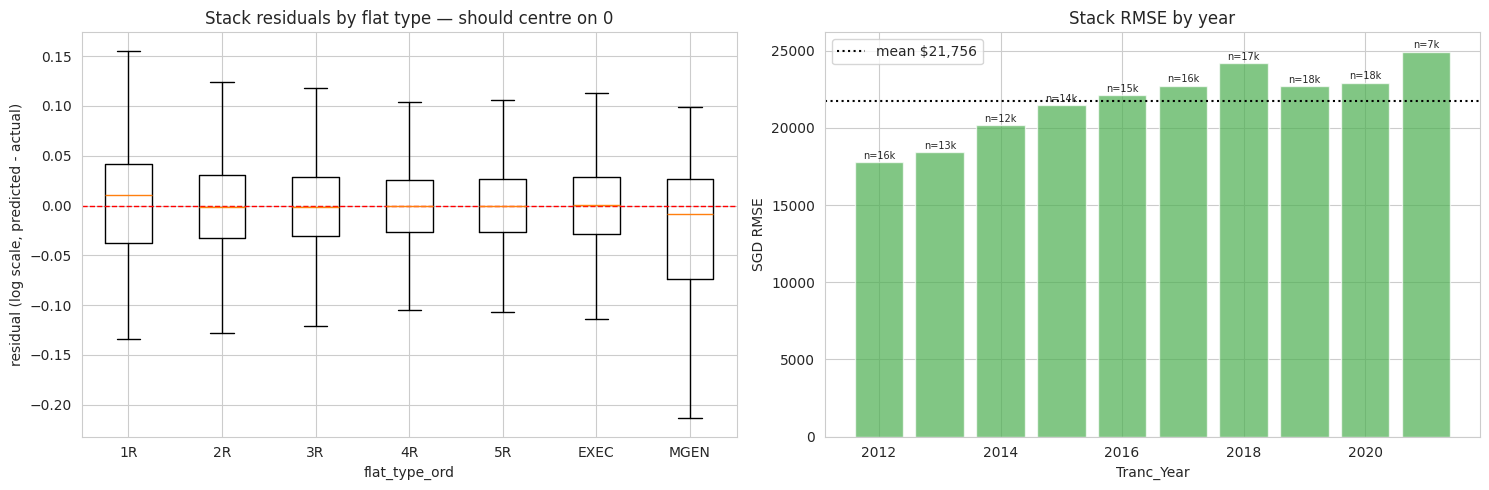


If the box for flat type X sits clearly above/below zero, the model is biased on that segment.
If RMSE rises sharply in the most recent year, there's temporal drift the lag features aren't catching.


In [31]:
resid_log = stack_oof - y_arr   # log-scale residuals
ft_arr    = train['flat_type_ord'].values
yr        = train['Tranc_Year'].values

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Boxplot of log residuals by flat type
ft_labels = {1:'1R',2:'2R',3:'3R',4:'4R',5:'5R',6:'EXEC',7:'MGEN'}
ft_present = sorted(np.unique(ft_arr))
data = [resid_log[ft_arr == ft] for ft in ft_present]
axes[0].boxplot(data, labels=[ft_labels.get(ft, str(ft)) for ft in ft_present], showfliers=False)
axes[0].axhline(0, color='red', ls='--', lw=1)
axes[0].set_xlabel('flat_type_ord'); axes[0].set_ylabel('residual (log scale, predicted - actual)')
axes[0].set_title('Stack residuals by flat type — should centre on 0')

# 2. RMSE by year
years = sorted(np.unique(yr))
rmse_by_year = []
n_by_year    = []
for ye in years:
    mk = yr == ye
    rmse_by_year.append(rmse_sgd(y_arr[mk], stack_oof[mk]))
    n_by_year.append(int(mk.sum()))
ax2 = axes[1]
bars = ax2.bar(years, rmse_by_year, color='#4CAF50', alpha=0.7)
ax2.set_xlabel('Tranc_Year'); ax2.set_ylabel('SGD RMSE'); ax2.set_title('Stack RMSE by year')
ax2.axhline(np.mean(rmse_by_year), color='black', ls=':', label=f'mean ${np.mean(rmse_by_year):,.0f}')
for b, n in zip(bars, n_by_year):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+200, f'n={n//1000}k', ha='center', fontsize=7)
ax2.legend()

plt.tight_layout(); plt.show()

print("\nIf the box for flat type X sits clearly above/below zero, the model is biased on that segment.")
print("If RMSE rises sharply in the most recent year, there's temporal drift the lag features aren't catching.")

## 15. 100% refit for submission

Each base is retrained on the **full training set** (no held-out fold) using the average best-iteration count from CV. The stack meta-weights stay frozen — they were learned on honest OOF predictions and should not be re-fitted to refit-time data.

> 💡 **Lesson — refit on full data, freeze the meta.** Training the bases on more data reduces their variance; refitting the meta on refit-time predictions is leakage (the meta would see the bases' in-sample fits, which are wildly optimistic).

In [32]:
test_preds = {}

# LGBM-Huber seed-avg refit
t = time.time()
p = np.zeros(len(test))
for sd in SEEDS:
    m = lgb.LGBMRegressor(**{k: v for k, v in LGB_HUBER_PARAMS.items() if k != 'n_estimators'},
                          random_state=sd, n_estimators=lgbh_avg_iter)
    m.fit(X_lgb, y, categorical_feature=CAT_COLS)
    p += m.predict(T_lgb) / len(SEEDS)
test_preds['LGB-Huber'] = p; lap('lgbh_refit', t)

# LGBM-MSE seed-avg refit
t = time.time()
p = np.zeros(len(test))
for sd in SEEDS:
    m = lgb.LGBMRegressor(**{k: v for k, v in LGB_MSE_PARAMS.items() if k != 'n_estimators'},
                          random_state=sd, n_estimators=lgbm_avg_iter)
    m.fit(X_lgb, y, categorical_feature=CAT_COLS)
    p += m.predict(T_lgb) / len(SEEDS)
test_preds['LGB-MSE'] = p; lap('lgbm_refit', t)

# XGB refit (strip early_stopping_rounds + n_estimators, set fresh n_estimators)
t = time.time()
xgb_full = xgb.XGBRegressor(**{k: v for k, v in XGB_PARAMS.items() if k not in ('early_stopping_rounds','n_estimators')},
                             n_estimators=xgb_avg_iter)
xgb_full.fit(X_dense, y.values)
test_preds['XGB'] = xgb_full.predict(T_dense); lap('xgb_refit', t)

# Segment refit — one model per segment, fall back to LGBM-MSE for too-small segments
t = time.time()
seg_test = test_preds['LGB-MSE'].copy()  # backstop
test_seg_arr = test[SEG_COL].values
for seg in np.unique(seg_arr):
    seg_tr_mask = seg_arr == seg
    seg_te_mask = test_seg_arr == seg
    if seg_tr_mask.sum() < 100 or seg_te_mask.sum() == 0:
        continue
    m = lgb.LGBMRegressor(**SEG_LGB_PARAMS)
    m.fit(X_lgb.loc[seg_tr_mask], y.loc[seg_tr_mask], categorical_feature=CAT_COLS)
    seg_test[seg_te_mask] = m.predict(T_lgb.loc[seg_te_mask])
test_preds['SegBlend'] = seg_test; lap('seg_refit', t)

test_mat_full = np.column_stack([test_preds[n] for n in base_names])
print(f"\nTest matrix: {test_mat_full.shape}")

  [lgbh_refit] 220.5s
  [lgbm_refit] 214.5s
  [xgb_refit] 104.6s
  [seg_refit] 82.7s

Test matrix: (16737, 4)


## 16. Submission

The output filename is `{date}_{stack_rmse}_likhong.csv` — embedding the CV score in the filename means historical submissions are self-documenting on disk.

> 💡 **Lesson — encode your CV score in the filename.** When a submission lands on the leaderboard you immediately know which CV gave it. After 14+ versions this is the only sane way to keep history.

In [33]:
final_log = meta.predict(test_mat_full)
final_sgd = np.expm1(final_log)
sub = pd.DataFrame({'id': test_ids, 'resale_price': final_sgd})
sub = sub[~sub['id'].isin([182002, 82198])].reset_index(drop=True)

today = datetime.date.today().strftime('%Y%m%d')
score = int(round(rmse_sgd(y_arr, stack_oof)))
out   = f'{OUT_DIR}/{today}_{score}_likhong.csv'
sub.to_csv(out, index=False)
print(f"Wrote {out}")
print(f"  rows={len(sub):,}  range=${sub['resale_price'].min():,.0f}–${sub['resale_price'].max():,.0f}")
print(f"  KFold stack RMSE: ${score:,}  (target $22,000 — v7 best $22,094)")
print(f"  Total time: {time.time()-T0:.1f}s")

Wrote /kaggle/working/20260430_21832_likhong.csv
  rows=16,735  range=$175,372–$1,176,194
  KFold stack RMSE: $21,832  (target $22,000 — v7 best $22,094)
  Total time: 6243.6s


## 17. Lessons learnt — v1 to v15

### Results

| | CV RMSE |
|---|---|
| Personal best (v7) | $22,094 |
| v14 stack | $21,831 |
| **v15 stack** | **$21,832** |

Stack beat the personal best. v15 matched v14 exactly after pruning 2 dead bases and a redundant feature — confirming the cuts were clean.

---

### Feature engineering

| # | Takeaway |
|---|---|
| FE-1 | **Features beat models.** The biggest CV jumps across v1–v14 came from new features (lag medians, KNN, target encoding), not new model families. |
| FE-2 | **Lag features must be strictly backward-looking.** Any rolling stat that touches the current row is leakage; always assert `lag.ym < target.ym`. |
| FE-3 | **Demote low-weight bases to features.** A signal the meta-learner weights at <0.05 costs full CV overhead as a base but is essentially free as a feature the GBDTs absorb. KNN was the case study here. |
| FE-4 | **Avoid redundant encodings.** The same signal as a raw column, a geo-cluster, *and* a target encoding triple-counts it. Trees tolerate redundancy; linear meta-learners do not. `price_tier_enc` was dropped for exactly this reason. |
| FE-5 | **Use native categoricals in LightGBM.** OHE on high-cardinality columns inflates the feature matrix and dilutes split candidates. LightGBM handles them natively and usually better. |
| FE-6 | **Target-encoding smoothing matters.** `smooth=0` overfits rare categories; `smooth=inf` collapses to the global mean. `smooth=20` is roughly "trust a category once it has ~20 samples." |

---

### Model fitting & stacking

| # | Takeaway |
|---|---|
| MF-1 | **CV scheme must match the test scheme.** Walk-forward CV is correct for future deployment; random KFold is correct for an i.i.d. hold-out leaderboard. Using walk-forward here cost ~$1k+ in ranking (v12/v13). |
| MF-2 | **Huber loss + seed averaging is a cheap robustness pair.** Huber stops fat-tail outliers from dominating gradients; 3-seed averaging costs only compute and buys ~$50–100 RMSE. |
| MF-3 | **Stack diversity requires algorithmic difference, not hyperparameter tweaks.** Two LGBMs with different `num_leaves` stay highly correlated. LGBM (leaf-wise) vs XGBoost (level-wise) gives the meta-learner genuinely orthogonal errors. |
| MF-4 | **Same family, different loss = useful stack diversity.** LGBM-Huber vs LGBM-MSE de-correlates errors enough for the meta-learner to benefit — a different model class is not always needed. |
| MF-5 | **Specialise when errors are heterogeneous across a discrete attribute.** A global model averages mistakes across segments. Per `flat_type` models captured dynamics the global model blurred, and the specialisation gain outweighed the smaller training-set penalty. |
| MF-6 | **Refit bases on full data; freeze meta weights.** Refitting the meta on in-sample base predictions is leakage — the meta would see wildly optimistic fits. Meta weights learned on honest OOF must stay frozen. |
| MF-7 | **Stacking votes must be honest.** Training the meta on in-fold predictions leaks validation labels into the meta; CV looks great, leaderboard tanks. |
| MF-8 | **Global RMSE hides segment-level failure.** Always slice residuals by price decile, flat type, and year. In v15: MAPE is flat at ~3.3–3.5% across all deciles, but absolute RMSE doubles from $15k (cheap flats) to $35k (top decile). |
| MF-9 | **Prune bases that earn zero or near-zero meta weight.** HGBT-Quantile (weight 0.000, +442s) and RandomForest (weight 0.060, +2,653s) were dead weight. Dropping them recovered wall time with no CV cost. |
